## Text Classification with RNNs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
labels = []
docs = []

with open('/content/drive/MyDrive/dataset/hamshahri-for-classification.txt', 'r') as f:
  for line in f:
    line = line.rstrip()
    res = line.split('@@@@@@@@@@')
    label = res[0]
    doc = res[1]
    labels.append(label)
    docs.append(doc)

In [ ]:
int_label = []

for label in labels:
  if label=='اجتماعی':
    int_label.append(0)
  if label=='ادب':
    int_label.append(1)
  if label=='اقتصاد':
    int_label.append(2)
  if label=='ورزش':
    int_label.append(3)    


In [ ]:
def clean(data):

  tokens = data.split()
  translation_table = str.maketrans('', '', "\"#$%&'()*+,-/:;<=>?@[\]^_`{|}~،؟!❊#$٪^&*)(ـ+=-؛:❊{}.")
  tokens = [w.translate(translation_table) for w in tokens]
  # tokens = [word.lower() for word in tokens] 
  return ' '.join(tokens)
 

In [ ]:
num_classes = 4
labels = int_label
docs = [clean(doc) for doc in docs]

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical

labels= to_categorical(labels, num_classes=num_classes)

In [ ]:
labels[0]

array([1., 0., 0., 0.], dtype=float32)

In [ ]:
from sklearn.model_selection import train_test_split

sentences_train, sentences_test, y_train, y_test = train_test_split(
   docs, labels, test_size=0.20, random_state=1000)

sentences_test, sentences_valid, y_test, y_valid = train_test_split(
   sentences_test, y_test, test_size=0.5, random_state=1000)

In [ ]:
maxlen = 100

In [ ]:
from keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(docs)

X_train = tokenizer.texts_to_sequences(sentences_train)
X_test = tokenizer.texts_to_sequences(sentences_test)
X_val = tokenizer.texts_to_sequences(sentences_valid)

vocab_size = len(tokenizer.word_index) + 1 

In [ ]:
from keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
X_test = pad_sequences(X_test, padding='post', maxlen=maxlen)
X_val = pad_sequences(X_val, padding='post', maxlen=maxlen)


### Architecture of the proposed model

![](https://drive.google.com/uc?export=view&id=1xmof9WLKZKlrcwwAQi81hMTX1G7J26v-)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, LSTM, GRU, Embedding

embedding_dim = 100

model = Sequential()
model.add(Embedding(input_dim=vocab_size, 
                           output_dim=embedding_dim, 
                           input_length=maxlen,
                           trainable=True))

model.add(Bidirectional(GRU(300, dropout=0.2,  return_sequences=True)))
model.add(Bidirectional(GRU(200, dropout=0.2,  return_sequences=True)))
model.add(Bidirectional(GRU(100, dropout=0.2,)))
model.add(Dense(100, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 100, 100)          8014200   
_________________________________________________________________
bidirectional (Bidirectional (None, 100, 600)          723600    
_________________________________________________________________
bidirectional_1 (Bidirection (None, 100, 400)          962400    
_________________________________________________________________
bidirectional_2 (Bidirection (None, 200)               301200    
_________________________________________________________________
dense (Dense)                (None, 100)               20100     
_________________________________________________________________
dense_1 (Dense)              (None, 4)                 404       
Total params: 10,021,904
Trainable params: 10,021,904
Non-trainable params: 0
____________________________________________

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_path = '/content/drive/MyDrive/models/model-{epoch:03d}-{val_accuracy:03f}.ckpt'

cp_callback = ModelCheckpoint(
    filepath=checkpoint_path, 
    monitor = 'val_accuracy',
    mode = 'max',
    save_best_only=True)

In [ ]:
import tensorflow as tf

tf.keras.utils.plot_model(model, to_file='/content/model.png', show_shapes=True)

In [ ]:
history = model.fit(X_train, y_train,
                    epochs=20,
                    validation_data=(X_val, y_valid),
                    batch_size=100,
                    callbacks=[cp_callback])

Epoch 1/20
80/80 [==============================] - 34s 278ms/step - loss: 0.8811 - accuracy: 0.6041 - val_loss: 0.4904 - val_accuracy: 0.7610


INFO:tensorflow:Assets written to: /content/drive/MyDrive/models/model-001-0.761000.ckpt/assets


INFO:tensorflow:Assets written to: /content/drive/MyDrive/models/model-001-0.761000.ckpt/assets


Epoch 2/20
80/80 [==============================] - 20s 245ms/step - loss: 0.3827 - accuracy: 0.8454 - val_loss: 0.4002 - val_accuracy: 0.8420


INFO:tensorflow:Assets written to: /content/drive/MyDrive/models/model-002-0.842000.ckpt/assets


...

INFO:tensorflow:Assets written to: /content/drive/MyDrive/models/model-016-0.858000.ckpt/assets


Epoch 17/20
80/80 [==============================] - 21s 257ms/step - loss: 1.3247e-04 - accuracy: 1.0000 - val_loss: 0.8251 - val_accuracy: 0.8620


INFO:tensorflow:Assets written to: /content/drive/MyDrive/models/model-017-0.862000.ckpt/assets


INFO:tensorflow:Assets written to: /content/drive/MyDrive/models/model-017-0.862000.ckpt/assets


Epoch 18/20
80/80 [==============================] - 20s 253ms/step - loss: 9.8718e-05 - accuracy: 1.0000 - val_loss: 0.8375 - val_accuracy: 0.8590
Epoch 19/20
80/80 [==============================] - 20s 254ms/step - loss: 7.4821e-05 - accuracy: 1.0000 - val_loss: 0.8486 - val_accuracy: 0.8600
Epoch 20/20
80/80 [==============================] - 20s 254ms/step - loss: 7.0993e-05 - accuracy: 1.0000 - val_loss: 0.8534 - val_accuracy: 0.8620


In [ ]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

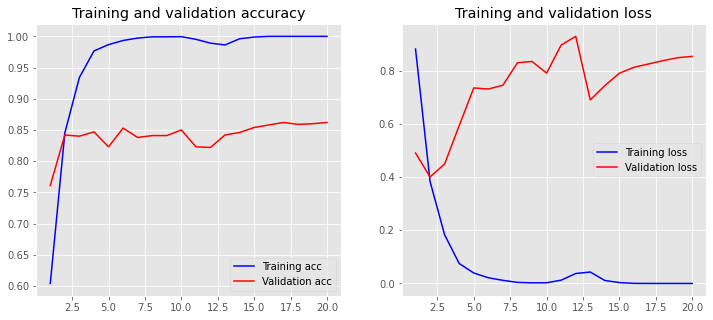

In [ ]:
plot_history(history)

In [ ]:
from keras.models import load_model
model = load_model('/content/drive/MyDrive/models/model-017-0.862000.ckpt')

In [ ]:
preds = model.evaluate(X_test, y_test, verbose=0)

In [ ]:
preds

[0.8451567888259888, 0.8709999918937683]